In [1]:
from functions import *
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation


In [2]:
file_list = [
    "data/111/PWS_NASA_Dataset111_rrf.faa",
    "data/111/PWS_NASA_Dataset111_u.faa",
    "data/111/PWS_NASA_Dataset111_v.faa",
    "data/111/PWS_NASA_Dataset111_w.faa"
]
print_pws_files_data(file_list)

Processing file: data/111/PWS_NASA_Dataset111_rrf.faa
Metadata:
  Title: Case #1-11:  DFW Accident Case, Wet Microburst, Rain and Hail
  Variable: RRF
  Dimensions (x, y, z): (161, 161, 41)
  Simulation Time (seconds): 660.0
  Origin (x, y, z) in meters: (-4000.0, -4000.0, 0.0)
  Resolution (dx, dy, dz) in meters: (50.0, 50.0, 50.0)

Sample Data:
[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 ...

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0

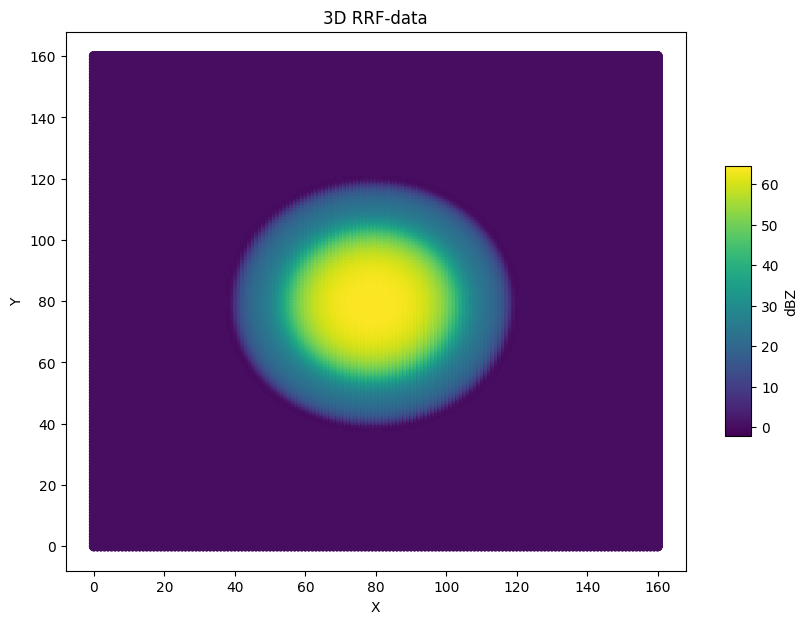

In [3]:
file_path = "data/111/PWS_NASA_Dataset111_rrf.faa"
data = read_pws_file(file_path)

u_data = data['data']  # ix, iy, iz
x_dim, y_dim, z_dim = u_data.shape

x = np.arange(x_dim)
y = np.arange(y_dim)
z = np.arange(z_dim)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

X_flat = X.flatten()
Y_flat = Y.flatten()
Z_flat = Z.flatten()
U_flat = u_data.flatten()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111)
scatter = ax.scatter(X_flat, Y_flat, Z_flat, c=U_flat, cmap='viridis')

cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('dBZ')

ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.title('3D RRF-data')
plt.show()

In [4]:
u_data = read_pws_file("data/111/PWS_NASA_Dataset111_u.faa")
v_data = read_pws_file("data/111/PWS_NASA_Dataset111_v.faa")
w_data = read_pws_file("data/111/PWS_NASA_Dataset111_w.faa")

z_slice = 3


In [5]:

origin = u_data['origin_m']  
dx, dy, dz = u_data['resolution_m']  
ix, iy, iz = u_data['dimensions']  

# пример: центр сетки)
x0 = 0
y0 = 0
z0 = 0

x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Вектор смещения от выбранной точки
delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0

r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)

# Радиальная скорость
V_radial = (u_data['data'] * delta_x + 
            v_data['data'] * delta_y + 
            w_data['data'] * delta_z) / r

V_radial = np.nan_to_num(V_radial, nan=0.0)

C:\Users\user\AppData\Local\Temp\ipykernel_3132\982502328.py:23: RuntimeWarning: invalid value encountered in divide
  V_radial = (u_data['data'] * delta_x +


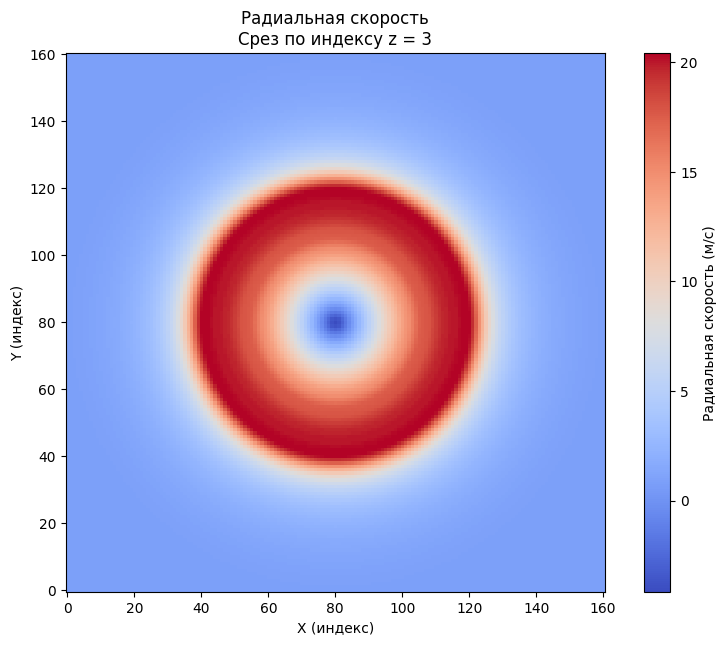

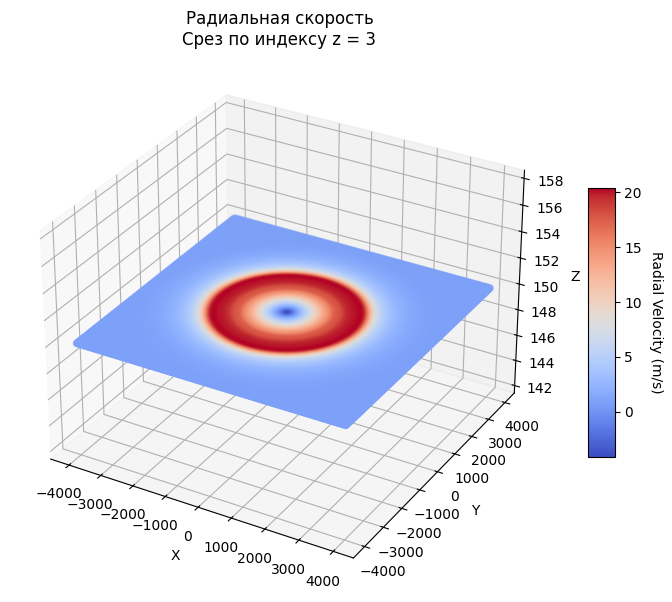

In [6]:
plt.figure(figsize=(10, 7))
plt.imshow(V_radial[:, :, z_slice], cmap='coolwarm', origin='lower')
plt.colorbar(label='Радиальная скорость (м/с)')
plt.title(f'Радиальная скорость\nСрез по индексу z = {z_slice}')
plt.xlabel('X (индекс)')
plt.ylabel('Y (индекс)')
plt.show()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X[:, :, z_slice].flatten(),
    Y[:, :, z_slice].flatten(),
    Z[:, :, z_slice].flatten(),
    c=V_radial[:, :, z_slice].flatten(),
    cmap='coolwarm'
)

cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('Radial Velocity (m/s)', rotation=270, labelpad=15)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title(f"Радиальная скорость\nСрез по индексу z = {z_slice}")
plt.show()

In [7]:

ix, iy, iz = u_data['dimensions']
xstart, ystart, zstart = u_data['origin_m']
dx, dy, dz = u_data['resolution_m']

#сетки координат
x = np.arange(xstart, xstart + ix * dx, dx)
y = np.arange(ystart, ystart + iy * dy, dy)
z = np.arange(zstart, zstart + iz * dz, dz)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Заданная точка
x0, y0, z0 = 0, 0, 0 

# Вычисление разностей координат
delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0

distance = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)

distance[distance == 0] = 1e-10

# Расчет радиальной скорости
U = u_data['data']
V = v_data['data']
W = w_data['data']
radial_velocity = (U * delta_x + V * delta_y + W * delta_z) / distance

print("Размерность поля радиальных скоростей:", radial_velocity.shape)

Размерность поля радиальных скоростей: (161, 161, 41)


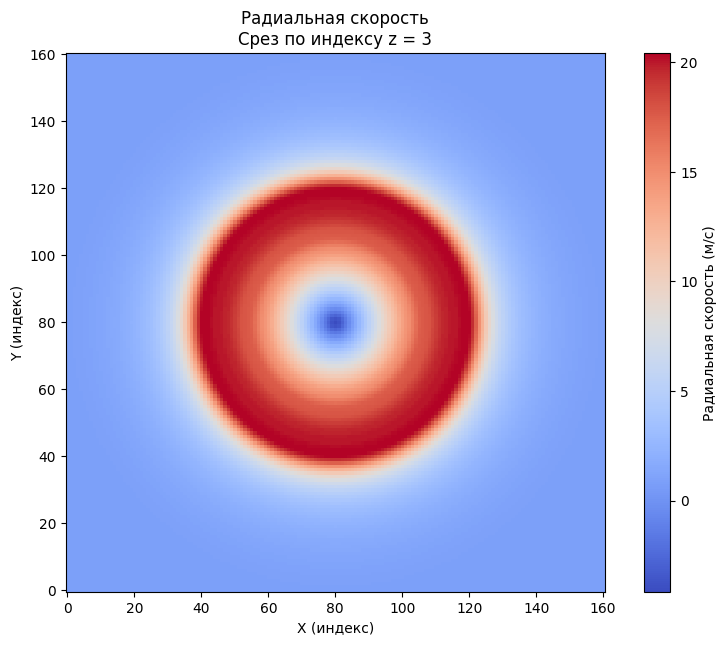

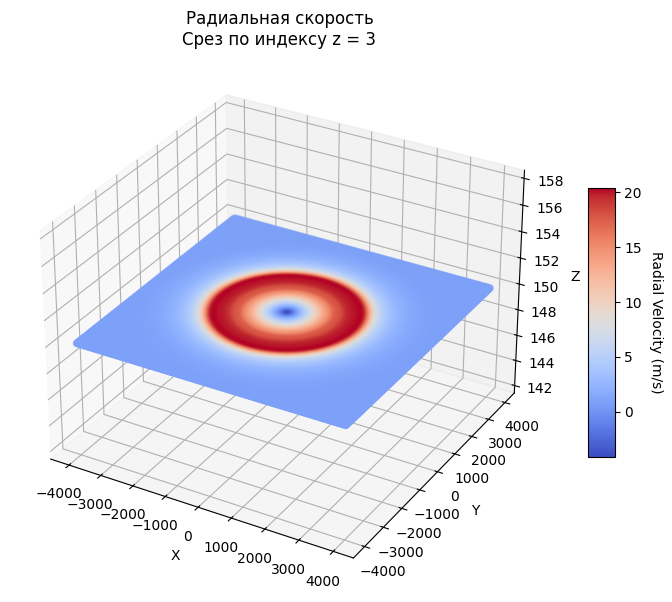

In [8]:
plt.figure(figsize=(10, 7))
plt.imshow(radial_velocity[:, :, z_slice], cmap='coolwarm', origin='lower')
plt.colorbar(label='Радиальная скорость (м/с)')
plt.title(f'Радиальная скорость\nСрез по индексу z = {z_slice}')
plt.xlabel('X (индекс)')
plt.ylabel('Y (индекс)')
plt.show()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X[:, :, z_slice].flatten(),
    Y[:, :, z_slice].flatten(),
    Z[:, :, z_slice].flatten(),
    c=radial_velocity[:, :, z_slice].flatten(),
    cmap='coolwarm'
)

cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('Radial Velocity (m/s)', rotation=270, labelpad=15)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title(f"Радиальная скорость\nСрез по индексу z = {z_slice}")
plt.show()

In [9]:
u_data = read_pws_file("data/Official_Mcy_dataset/mcy_u.faa")
v_data = read_pws_file("data/Official_Mcy_dataset/mcy_v.faa")
w_data = read_pws_file("data/Official_Mcy_dataset/mcy_w.faa")



In [10]:
origin = u_data['origin_m']  
dx, dy, dz = u_data['resolution_m']  
ix, iy, iz = u_data['dimensions']  


x0 = 0
y0 = 0
z0 = 0

x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0

r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)

V_radial = (u_data['data'] * delta_x + 
            v_data['data'] * delta_y + 
            w_data['data'] * delta_z) / r

V_radial = np.nan_to_num(V_radial, nan=0.0)

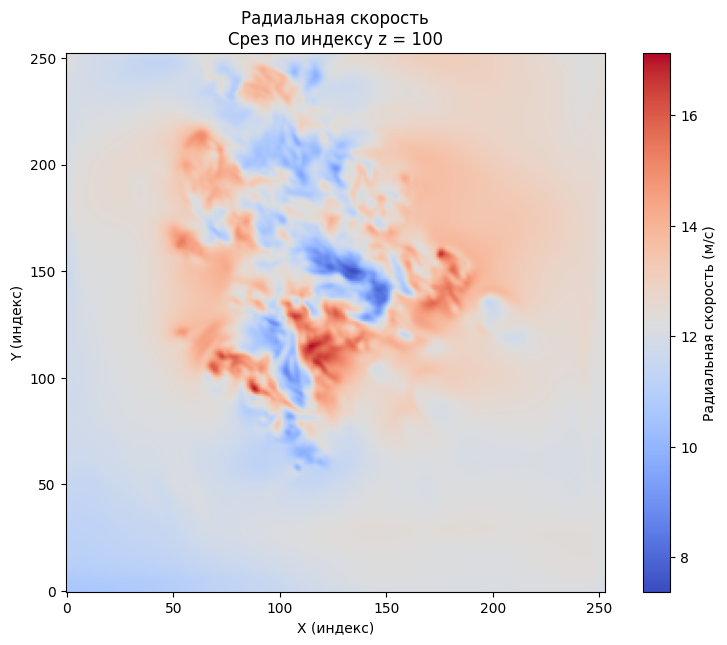

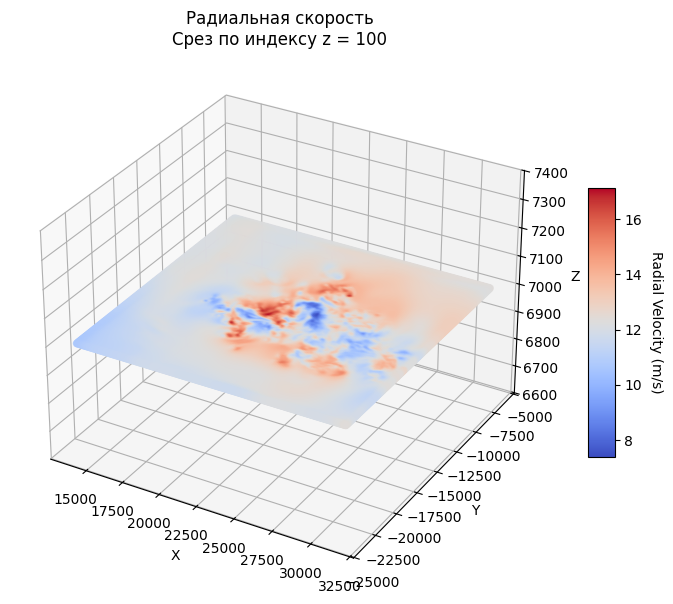

In [11]:
z_slice = 100
plt.figure(figsize=(10, 7))
plt.imshow(V_radial[:, :, z_slice], cmap='coolwarm', origin='lower')
plt.colorbar(label='Радиальная скорость (м/с)')
plt.title(f'Радиальная скорость\nСрез по индексу z = {z_slice}')
plt.xlabel('X (индекс)')
plt.ylabel('Y (индекс)')
plt.show()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X[:, :, z_slice].flatten(),
    Y[:, :, z_slice].flatten(),
    Z[:, :, z_slice].flatten(),
    c=V_radial[:, :, z_slice].flatten(),
    cmap='coolwarm'
)

cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('Radial Velocity (m/s)', rotation=270, labelpad=15)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title(f"Радиальная скорость\nСрез по индексу z = {z_slice}")
plt.show()

In [12]:
# # u_data = read_pws_file("data/Official_Mcy_dataset/mcy_u.faa")
# # v_data = read_pws_file("data/Official_Mcy_dataset/mcy_v.faa")
# # w_data = read_pws_file("data/Official_Mcy_dataset/mcy_w.faa")
# u_data = read_pws_file("data/111/PWS_NASA_Dataset111_u.faa")
# v_data = read_pws_file("data/111/PWS_NASA_Dataset111_v.faa")
# w_data = read_pws_file("data/111/PWS_NASA_Dataset111_w.faa")

# U = u_data['data']  
# V = v_data['data']  
# W = w_data['data'] 
# dx = u_data['resolution_m'][0]  
# v_aircraft = 77.2
# g = 9.81

# dudx = np.gradient(U, dx, axis=0)

# wx = U #dudx * v_aircraft

# wz = W
# F = (wx / g) - (wz / v_aircraft)

# F = np.nan_to_num(F, nan=0.0)

In [13]:
# z_slice = 20
# plt.figure(figsize=(10, 7))
# plt.imshow(F[:, :, z_slice], cmap='coolwarm', origin='lower')
# plt.colorbar(label='F-фактор')
# plt.title(f'F-фактор (срез z = {z_slice})')
# plt.xlabel('Координата X')
# plt.ylabel('Координата Y')
# plt.show()

In [17]:
u_data = read_pws_file("data/111/PWS_NASA_Dataset111_u.faa")
v_data = read_pws_file("data/111/PWS_NASA_Dataset111_v.faa")
w_data = read_pws_file("data/111/PWS_NASA_Dataset111_w.faa")

origin = u_data['origin_m']  
dx, dy, dz = u_data['resolution_m']  
ix, iy, iz = u_data['dimensions']  

In [18]:
V_a = 77.2     
g = 9.81        
L = 1000      

delta_x = int(500 / dx)
delta_y = int(500 / dy)

FBAR_NS = np.zeros((ix, iy, iz))
FBAR_EW = np.zeros((ix, iy, iz))

for i in range(ix):
    for j in range(iy):
        for k in range(iz):
            if j - delta_y >= 0 and j + delta_y < iy:
                v_diff = v_data['data'][j + delta_y, i, k] - v_data['data'][j - delta_y, i, k]
                sum_w_ns = np.sum(w_data['data'][j - delta_y:j + delta_y + 1, i, k])
                FBAR_NS[i, j, k] = (V_a / (g * L)) * v_diff - (dy / (L * V_a)) * sum_w_ns
            
            if i - delta_x >= 0 and i + delta_x < ix:
                u_diff = u_data['data'][i + delta_x, j, k] - u_data['data'][i - delta_x, j, k]
                sum_w_ew = np.sum(w_data['data'][i - delta_x:i + delta_x + 1, j, k])
                FBAR_EW[i, j, k] = (V_a / (g * L)) * u_diff - (dx / (L * V_a)) * sum_w_ew
                
                
FBAR_NS = np.nan_to_num(FBAR_NS, nan=0.0)
FBAR_EW = np.nan_to_num(FBAR_EW, nan=0.0)

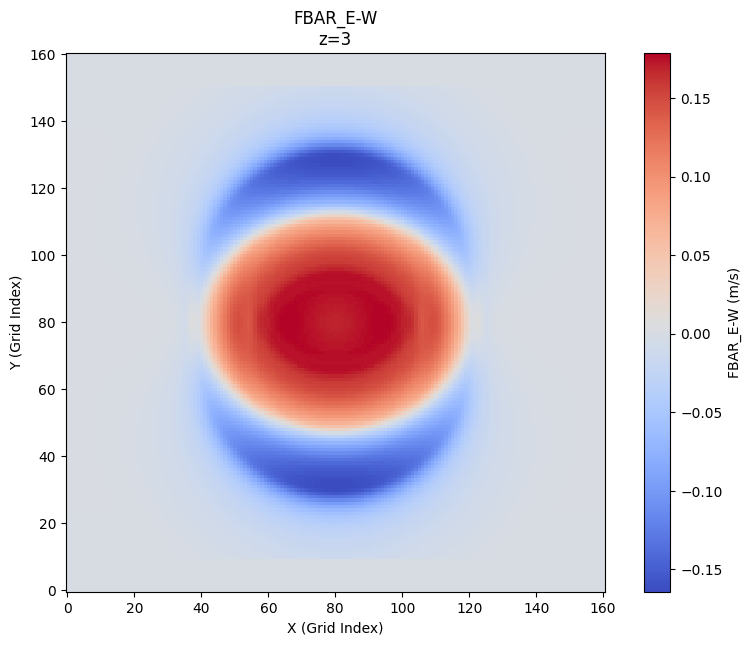

In [21]:
z_slice = 3
plt.figure(figsize=(10, 7))
plt.imshow(FBAR_EW[:, :, z_slice], cmap='coolwarm', origin='lower')
plt.colorbar(label='FBAR_E-W (m/s)')
plt.title(f'FBAR_E-W\nz={z_slice}')
plt.xlabel('X (Grid Index)')
plt.ylabel('Y (Grid Index)')
plt.show()

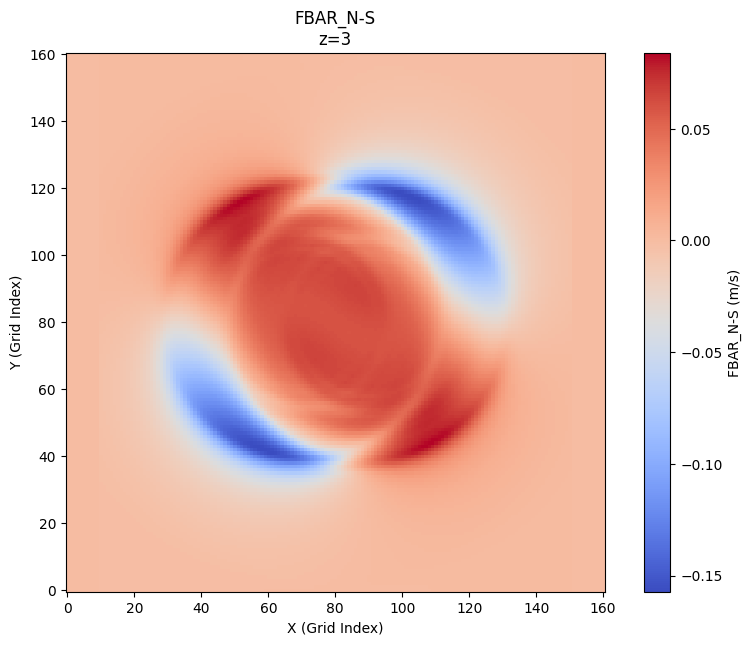

In [22]:
z_slice = 3
plt.figure(figsize=(10, 7))
plt.imshow(FBAR_NS[:, :, z_slice], cmap='coolwarm', origin='lower')
plt.colorbar(label='FBAR_N-S (m/s)')
plt.title(f'FBAR_N-S\nz={z_slice}')
plt.xlabel('X (Grid Index)')
plt.ylabel('Y (Grid Index)')
plt.show()

In [ ]:
def compute_fbar_fixed_direction(u, v, w, Va, dx, dy, dz, direction='north_south'):
    if direction == 'north_south':
        delta_v = v[:, int(dy/2):, :] - v[:, :-int(dy/2), :]
        sum_w = np.sum(w[:, int(dy/2):, :], axis=1)
        fbar = (Va / (g * L)) * delta_v - (dx * dy) / (L * Va) * sum_w
    elif direction == 'east_west':
        delta_u = u[int(dx/2):, :, :] - u[:-int(dx/2), :, :]
        sum_w = np.sum(w[int(dx/2):, :, :], axis=0)
        fbar = (Va / (g * L)) * delta_u - (dx * dy) / (L * Va) * sum_w
    else:
        raise ValueError("Invalid direction. Use 'north_south' or 'east_west'.")
    
    return fbar

fbar_ew = compute_fbar_fixed_direction(u_data['data'], v_data['data'], w_data['data'], V_a, dx, dy, dz, direction='east_west')

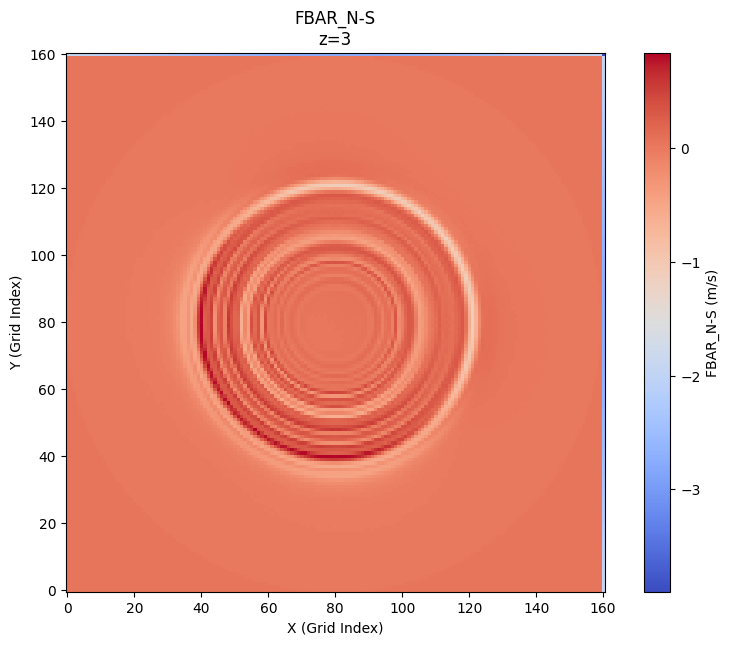

In [31]:
z_slice = 3
plt.figure(figsize=(10, 7))
plt.imshow(horizontal_term[:, :, z_slice], cmap='coolwarm', origin='lower')
plt.colorbar(label='FBAR_N-S (m/s)')
plt.title(f'FBAR_N-S\nz={z_slice}')
plt.xlabel('X (Grid Index)')
plt.ylabel('Y (Grid Index)')
plt.show()